# Random Forest and Neural Network Hand on Example

R² score: 0.933
Mean Absolute Error: 4.08 % yield


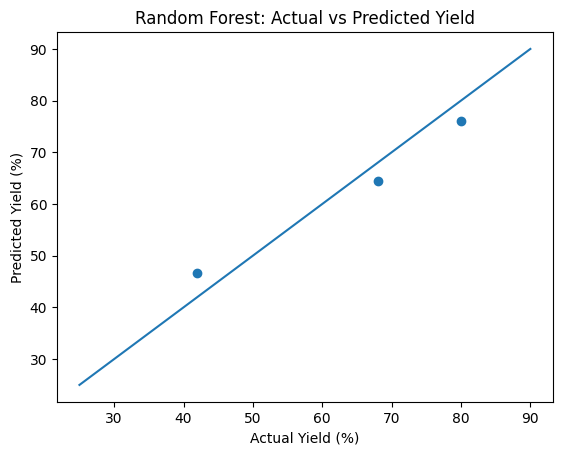

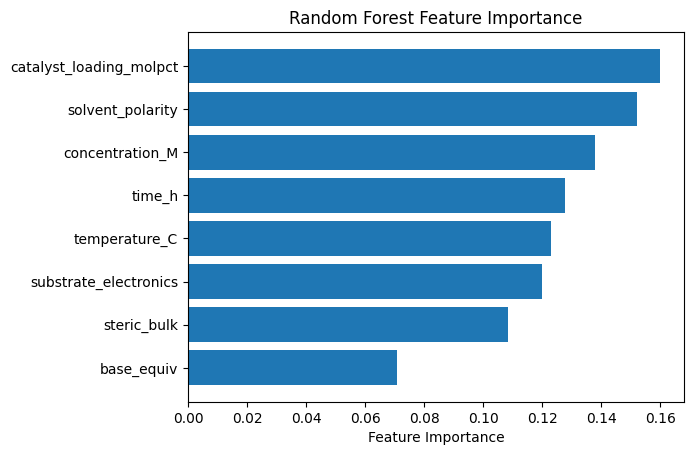

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------------
# 1. Load the dataset
# -----------------------------
data = {
    "temperature_C": [60,80,100,40,90,110,70,120,50,85,95,65],
    "time_h": [2,4,6,1,5,8,3,10,2,4,6,3],
    "catalyst_loading_molpct": [1.0,1.5,2.0,0.5,2.0,3.0,1.0,3.0,0.8,1.5,2.0,1.0],
    "base_equiv": [2.0,2.5,3.0,1.5,2.0,3.5,2.0,4.0,1.8,2.5,3.0,2.0],
    "concentration_M": [0.2,0.3,0.5,0.1,0.4,0.6,0.25,0.8,0.15,0.35,0.45,0.2],
    "solvent_polarity": [0.65,0.70,0.75,0.60,0.72,0.80,0.68,0.85,0.62,0.71,0.74,0.66],
    "substrate_electronics": [-0.5,-0.2,0.1,-0.8,0.0,0.3,-0.3,0.5,-0.6,-0.1,0.2,-0.4],
    "steric_bulk": [0.3,0.4,0.6,0.2,0.5,0.7,0.4,0.8,0.3,0.5,0.6,0.3],
    "yield_percent": [42,65,78,25,72,85,55,90,35,68,80,50]
}

df = pd.DataFrame(data)

X = df.drop("yield_percent", axis=1)
y = df["yield_percent"]

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------
# 3. Train Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# -----------------------------
# 4. Predictions & metrics
# -----------------------------
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f} % yield")

# -----------------------------
# 5. Visualization 1: Predicted vs Actual
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual Yield (%)")
plt.ylabel("Predicted Yield (%)")
plt.title("Random Forest: Actual vs Predicted Yield")
plt.show()

# -----------------------------
# 6. Visualization 2: Feature Importance
# -----------------------------
importances = rf.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure()
plt.barh(features[indices], importances[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


In [37]:
df

,temperature_C,time_h,catalyst_loading_molpct,base_equiv,concentration_M,solvent_polarity,substrate_electronics,steric_bulk,yield_percent
0,60,2,1.0,2.0,0.20,0.65,-0.5,0.3,42
1,80,4,1.5,2.5,0.30,0.70,-0.2,0.4,65
2,100,6,2.0,3.0,0.50,0.75,0.1,0.6,78
3,40,1,0.5,1.5,0.10,0.60,-0.8,0.2,25
4,90,5,2.0,2.0,0.40,0.72,0.0,0.5,72
5,110,8,3.0,3.5,0.60,0.80,0.3,0.7,85
6,70,3,1.0,2.0,0.25,0.68,-0.3,0.4,55
7,120,10,3.0,4.0,0.80,0.85,0.5,0.8,90
8,50,2,0.8,1.8,0.15,0.62,-0.6,0.3,35
9,85,4,1.5,2.5,0.35,0.71,-0.1,0.5,68


In [4]:
pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached fonttools-4.60.2-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.8 MB)

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 9.4 MB/s eta 0:00:00
  Using cached scipy-1.13.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 35.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached fonttools-4.60.2-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.8 MB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Baseline Random Forest
R² score: 0.933
MAE: 4.08 % yield

Best hyperparameters found:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100} 

Tuned Random Forest
R² score: 0.932
MAE: 4.12 % yield


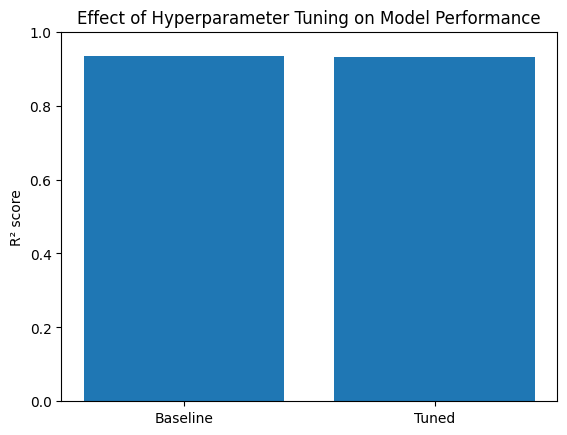

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------------
# 1. Load the dataset
# -----------------------------
data = {
    "temperature_C": [60,80,100,40,90,110,70,120,50,85,95,65],
    "time_h": [2,4,6,1,5,8,3,10,2,4,6,3],
    "catalyst_loading_molpct": [1.0,1.5,2.0,0.5,2.0,3.0,1.0,3.0,0.8,1.5,2.0,1.0],
    "base_equiv": [2.0,2.5,3.0,1.5,2.0,3.5,2.0,4.0,1.8,2.5,3.0,2.0],
    "concentration_M": [0.2,0.3,0.5,0.1,0.4,0.6,0.25,0.8,0.15,0.35,0.45,0.2],
    "solvent_polarity": [0.65,0.70,0.75,0.60,0.72,0.80,0.68,0.85,0.62,0.71,0.74,0.66],
    "substrate_electronics": [-0.5,-0.2,0.1,-0.8,0.0,0.3,-0.3,0.5,-0.6,-0.1,0.2,-0.4],
    "steric_bulk": [0.3,0.4,0.6,0.2,0.5,0.7,0.4,0.8,0.3,0.5,0.6,0.3],
    "yield_percent": [42,65,78,25,72,85,55,90,35,68,80,50]
}

df = pd.DataFrame(data)

X = df.drop("yield_percent", axis=1)
y = df["yield_percent"]

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------
# 3. Baseline Random Forest
# -----------------------------
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)

r2_baseline = r2_score(y_test, y_pred_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline Random Forest")
print(f"R² score: {r2_baseline:.3f}")
print(f"MAE: {mae_baseline:.2f} % yield\n")

# -----------------------------
# 4. Hyperparameter tuning
# -----------------------------
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", None]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    scoring="r2",
    cv=3
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best hyperparameters found:")
print(grid.best_params_, "\n")

# -----------------------------
# 5. Tuned model performance
# -----------------------------
y_pred_tuned = best_rf.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("Tuned Random Forest")
print(f"R² score: {r2_tuned:.3f}")
print(f"MAE: {mae_tuned:.2f} % yield")

# -----------------------------
# 6. Visualization: R² before vs after tuning
# -----------------------------
plt.figure()
plt.bar(
    ["Baseline", "Tuned"],
    [r2_baseline, r2_tuned]
)
plt.ylabel("R² score")
plt.title("Effect of Hyperparameter Tuning on Model Performance")
plt.ylim(0, 1)
plt.show()


Neural Network (MLP)
R² score: 0.953
Mean Absolute Error: 3.43 % yield


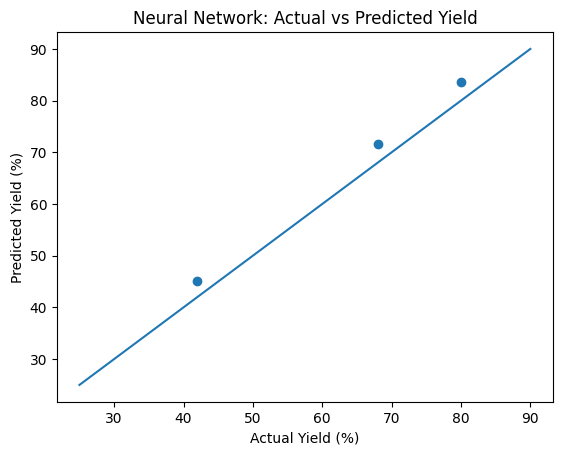

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -----------------------------
# 1. Load the dataset
# -----------------------------
data = {
    "temperature_C": [60,80,100,40,90,110,70,120,50,85,95,65],
    "time_h": [2,4,6,1,5,8,3,10,2,4,6,3],
    "catalyst_loading_molpct": [1.0,1.5,2.0,0.5,2.0,3.0,1.0,3.0,0.8,1.5,2.0,1.0],
    "base_equiv": [2.0,2.5,3.0,1.5,2.0,3.5,2.0,4.0,1.8,2.5,3.0,2.0],
    "concentration_M": [0.2,0.3,0.5,0.1,0.4,0.6,0.25,0.8,0.15,0.35,0.45,0.2],
    "solvent_polarity": [0.65,0.70,0.75,0.60,0.72,0.80,0.68,0.85,0.62,0.71,0.74,0.66],
    "substrate_electronics": [-0.5,-0.2,0.1,-0.8,0.0,0.3,-0.3,0.5,-0.6,-0.1,0.2,-0.4],
    "steric_bulk": [0.3,0.4,0.6,0.2,0.5,0.7,0.4,0.8,0.3,0.5,0.6,0.3],
    "yield_percent": [42,65,78,25,72,85,55,90,35,68,80,50]
}

df = pd.DataFrame(data)

X = df.drop("yield_percent", axis=1)
y = df["yield_percent"]

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------
# 3. Neural Network pipeline
# (scaling is essential for NNs)
# -----------------------------
nn = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        solver="adam",
        max_iter=5000,
        random_state=42
    ))
])

# -----------------------------
# 4. Train Neural Network
# -----------------------------
nn.fit(X_train, y_train)

# -----------------------------
# 5. Predictions & metrics
# -----------------------------
y_pred = nn.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Neural Network (MLP)")
print(f"R² score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f} % yield")

# -----------------------------
# 6. Visualization: Predicted vs Actual
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual Yield (%)")
plt.ylabel("Predicted Yield (%)")
plt.title("Neural Network: Actual vs Predicted Yield")
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8bcedd67-9d25-470e-9b46-c69b88907ac6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>